# 👩‍🏫 👩🏿‍🏫 What You’ll learn
Data cleaning and handling missing values
Exploratory Data Analysis (EDA) with visualization tools like Seaborn and Matplotlib
Feature engineering and correlation analysis
Building and comparing regression models (Linear Regression, SVM, Decision Trees, etc.)
Dimensionality reduction using PCA


# 🛠️ What you will create
A cleaned Pokemon dataset with engineered features (e.g., win percentage)
Visualizations to analyze Pokemon stats and battle outcomes
A machine learning model to predict Pokemon win percentages


# Dataset
Pokemon Dataset

pokemon.csv: Contains stats like HP, Attack, Type 1, Legendary, etc., for 800+ Pokemon.
combats.csv: Records 50,000 battle outcomes between Pokemon.


# What you need to do:
Data Preparation

Load and merge pokemon.csv and combats.csv.
Fix missing values:
Fill the missing Name for Pokemon #62 (Primeape).
Handle NaN values in Type 2 (mark as “None” if missing).
Calculate each Pokemon’s win percentage using the combat data.
Exploratory Analysis & Visualization

Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.
Plot a Seaborn pairplot or PairGrid for stats vs. win percentage.
Analyze the top 10 Pokemon by win percentage and their stats.
Machine Learning

Split data into training/testing sets (80/20 split).
Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
Compare model performance using Mean Absolute Error (MAE).


## 1. Import Libraries

In [1]:
# Pokemon Win Prediction Analysis

## 1. Import Libraries
# Import pandas
import pandas as pd

# Load pokemon dataset
pokemon_df = pd.read_csv('pokemon.csv')



In [2]:
## 2. Load Datasets
combats_df = pd.read_csv('combats.csv')

# Display first rows
pokemon_df.head()



,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
# Display first rows of combats dataset
combats_df.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [4]:
pokemon_df.shape

(800, 12)

In [5]:
combats_df.shape

(50000, 3)

In [6]:
# Display first rows of test dataset
tests_df = pd.read_csv('tests.csv')

tests_df.head()

,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


In [7]:
tests_df.shape

(10000, 2)

## 3. Data Preparation

In [8]:
### 3.1 Explore Dataset Structure
# Display dataset information
pokemon_df.info()

# Display summary statistics
pokemon_df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [9]:
### 3.2 Handle Missing Values

# Check missing values in each column
pokemon_df.isnull().sum()


,0
#,0
Name,1
Type 1,0
Type 2,386
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [10]:
# Find rows with missing Name
pokemon_df[pokemon_df['Name'].isnull()]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


In [11]:
# Fill missing Pokemon name with Primeape
pokemon_df.loc[pokemon_df['Name'].isnull(), 'Name'] = 'Primeape'

# Verify that the missing name was filled
pokemon_df[pokemon_df['#'] == 63]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,Primeape,Fighting,NaN,65,105,60,60,70,95,1,False


In [12]:
# Fill missing Type 2 values with 'None'
pokemon_df['Type 2'] = pokemon_df['Type 2'].fillna('None')

# Check missing values again
pokemon_df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


### Calculate Pokemon Win Percentage

In [13]:
# Count wins for each Pokemon
wins = combats_df['Winner'].value_counts()

# Display first rows
wins.head()

,count
Winner,
163,152
438,136
154,136
428,134
314,133


In [14]:
# Combine both Pokemon columns into one list
all_battles = pd.concat([
    combats_df['First_pokemon'],
    combats_df['Second_pokemon']
])

# Count total battles for each Pokemon
battles = all_battles.value_counts()

# Display first rows
battles.head()

,count
163,164
344,160
667,159
214,158
758,158


In [15]:
# Create DataFrame with battle counts
battle_stats = pd.DataFrame({
    'Battles': battles
})

# Add win counts
battle_stats['Wins'] = wins

# Replace missing wins with 0
battle_stats['Wins'] = battle_stats['Wins'].fillna(0)

# Calculate win percentage
battle_stats['Win_Percentage'] = (
    battle_stats['Wins'] / battle_stats['Battles']
)

# Display first rows
battle_stats.head()

,Battles,Wins,Win_Percentage
163,164,152.0,0.926829
344,160,104.0,0.650000
667,159,21.0,0.132075
214,158,130.0,0.822785
758,158,108.0,0.683544


In [16]:
# Convert index into a regular column
battle_stats = battle_stats.reset_index()

# Rename index column to match pokemon_df
battle_stats = battle_stats.rename(columns={'index': '#'})

# Merge Pokemon data with battle statistics
pokemon_stats = pokemon_df.merge(
    battle_stats,
    on='#',
    how='left'
)

# Display first rows
pokemon_stats.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Battles,Wins,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,0.278195
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,0.380165
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,0.560000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,0.491071


In [17]:
pokemon_stats.shape

(800, 15)

## 4. Exploratory Data Analysis (EDA)

### Dataset Overview

In [18]:
# Check missing values after merge
pokemon_stats[['Battles', 'Wins', 'Win_Percentage']].isnull().sum()

,0
Battles,16
Wins,16
Win_Percentage,16


In [21]:
# Display Pokemon without battle statistics
pokemon_stats[pokemon_stats['Win_Percentage'].isnull()][['#', 'Name']]

,#,Name
11,12,Blastoise
32,33,Sandshrew
45,46,Wigglytuff
65,66,Poliwag
77,78,Victreebel
89,90,Magneton
143,144,Ditto
182,183,Ariados
235,236,Ursaring
321,322,Hariyama


In [22]:
# Remove Pokemon with unknown win percentage
pokemon_stats = pokemon_stats.dropna(subset=['Win_Percentage'])

# Check dataset shape after removing rows
pokemon_stats.shape

(784, 15)

### Correlation Analysis

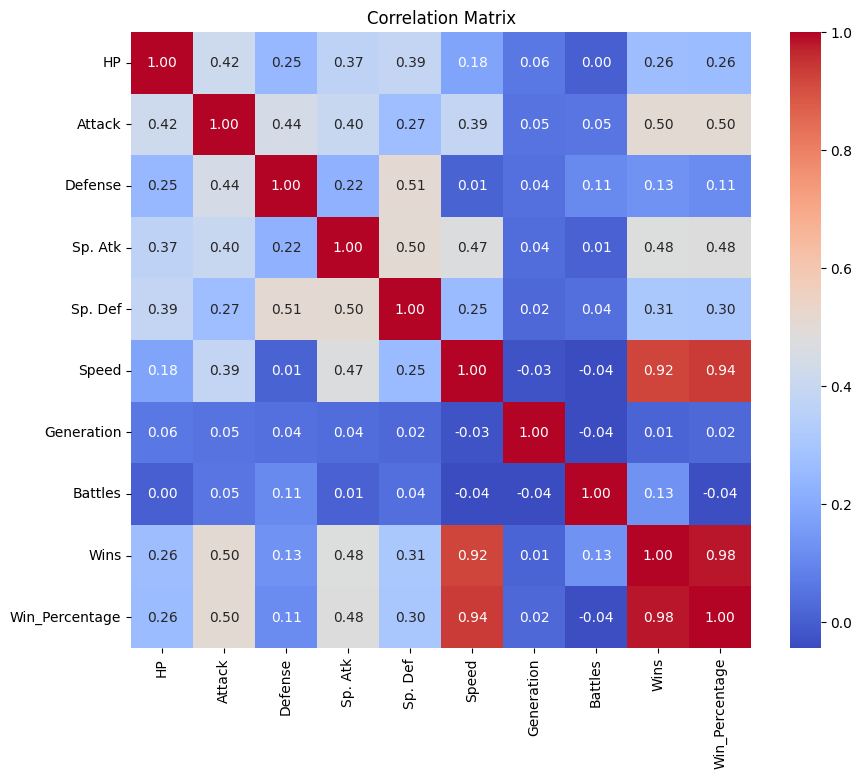

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_cols = [
    'HP',
    'Attack',
    'Defense',
    'Sp. Atk',
    'Sp. Def',
    'Speed',
    'Generation',
    'Battles',
    'Wins',
    'Win_Percentage'
]

# Calculate correlation matrix
corr_matrix = pokemon_stats[numeric_cols].corr()

# Create figure
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Add title
plt.title('Correlation Matrix')

plt.show()

### Top 10 Pokemon by win percentage

In [27]:
# Select top 10 Pokemon by win percentage
sorted_pokemon = pokemon_stats.sort_values(
    by='Win_Percentage',
    ascending=False
)

top10 = sorted_pokemon.head(10)
# Display top 10 Pokemon
top10

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Battles,Wins,Win_Percentage
154,155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,1,False,129.0,127.0,0.984496
512,513,Weavile,Dark,Ice,70,120,65,45,85,125,4,False,119.0,116.0,0.974790
703,704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,5,True,125.0,121.0,0.968000
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,1,False,119.0,115.0,0.966387
153,154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,1,False,141.0,136.0,0.964539
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,4,False,129.0,124.0,0.961240
726,727,Greninja,Water,Dark,72,95,67,103,71,122,6,False,127.0,122.0,0.960630
716,717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,5,False,123.0,118.0,0.959350
164,165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,1,True,125.0,119.0,0.952000
349,350,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,3,False,120.0,114.0,0.950000


### Pairplot Analysis - Pairplot of Pokemon Stats and Win Percentage

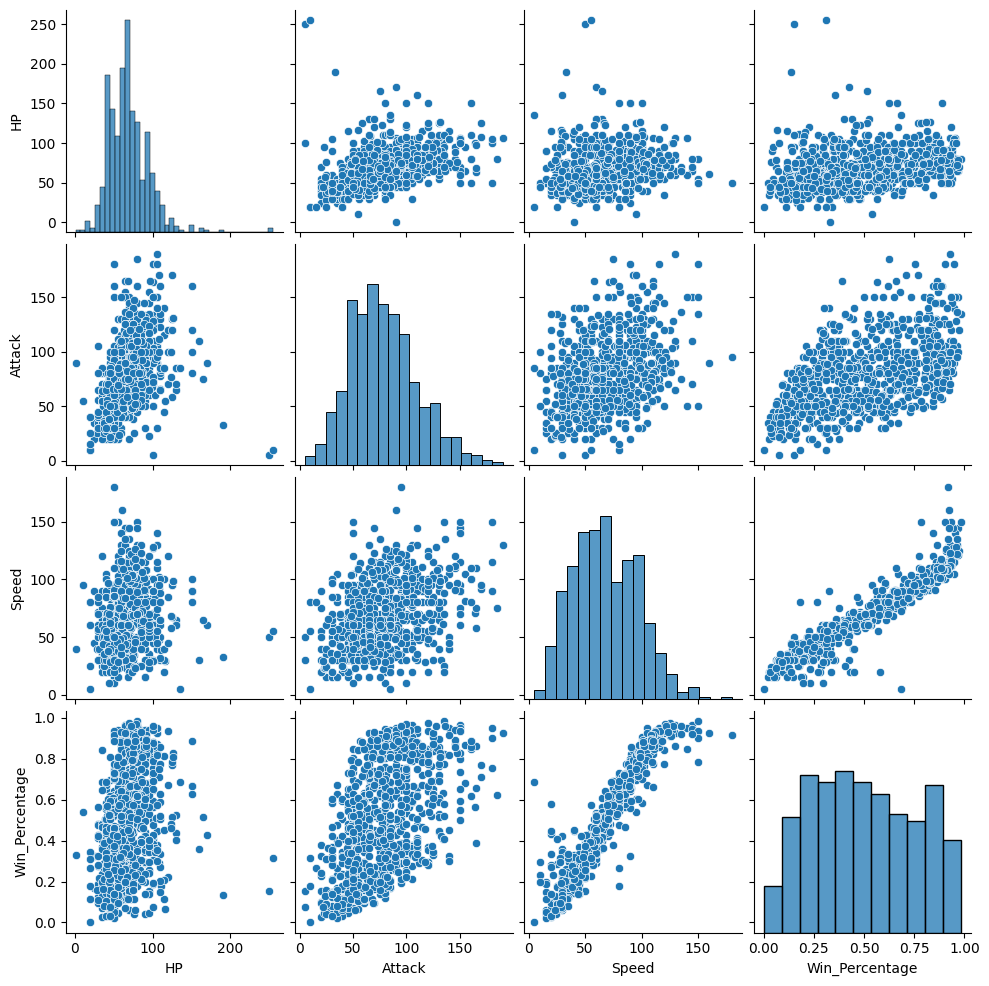

In [28]:
# Select key features for visualization
pairplot_cols = [
    'HP',
    'Attack',
    'Speed',
    'Win_Percentage'
]

# Create pairplot
sns.pairplot(
    pokemon_stats[pairplot_cols]
)

plt.show()

## Machine Learning Models

In [29]:
# Select target variable
y = pokemon_stats['Win_Percentage']

# Remove columns that should not be used as features
X = pokemon_stats.drop(
    columns=[
        'Win_Percentage',  # target
        'Name'             # text column
    ]
)

# Check shapes
print(X.shape)
print(y.shape)

# Display first rows
X.head()

(784, 13)
(784,)


,#,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Battles,Wins
0,1,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0
1,2,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0
2,3,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0
3,4,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0
4,5,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0


In [31]:
# Select features without data leakage
X = pokemon_stats.drop(
    columns=[
        'Name',
        'Win_Percentage',
        'Wins',
        'Battles'
    ]
)

# Check first rows
X.head()

,#,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Fire,None,39,52,43,60,50,65,1,False


In [33]:
X.head()

,#,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Fire,None,39,52,43,60,50,65,1,False


In [34]:
# Convert categorical variables into dummy variables
# drop_first=True removes one category from each group to avoid redundancy

X = pd.get_dummies(
    X,
    columns=['Type 1', 'Type 2'],
    drop_first=True
)

# Convert boolean column to integers (False=0, True=1)
X['Legendary'] = X['Legendary'].astype(int)

# Check result
X.head()

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type 1_Dark,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,1,45,49,49,65,65,45,1,0,False,...,False,False,False,False,False,True,False,False,False,False
1,2,60,62,63,80,80,60,1,0,False,...,False,False,False,False,False,True,False,False,False,False
2,3,80,82,83,100,100,80,1,0,False,...,False,False,False,False,False,True,False,False,False,False
3,4,80,100,123,122,120,80,1,0,False,...,False,False,False,False,False,True,False,False,False,False
4,5,39,52,43,60,50,65,1,0,False,...,False,False,False,True,False,False,False,False,False,False


In [35]:
X.dtypes.unique()

array([dtype('int64'), dtype('bool')], dtype=object)

In [36]:
# Remove Pokemon ID
X = X.drop(columns=['#'])

In [37]:
X = X.astype(int)

In [38]:
X.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type 1_Dark,Type 1_Dragon,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,45,49,49,65,65,45,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,60,62,63,80,80,60,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,80,82,83,100,100,80,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,80,100,123,122,120,80,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,39,52,43,60,50,65,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check dataset sizes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (627, 43)
X_test: (157, 43)
y_train: (627,)
y_test: (157,)


###*italicized text* Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Create Linear Regression model
lr_model = LinearRegression()

# Train model on training data
lr_model.fit(X_train, y_train)

# Predict win percentage for test data
lr_predictions = lr_model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
lr_mae = mean_absolute_error(y_test, lr_predictions)

# Display result
print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 0.05719149344102408


### Decision Tree Regressor

In [41]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Calculate MAE
dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

# Display result
print("Decision Tree MAE:", dt_mae)

Decision Tree MAE: 0.05259590924121336


### Random Forest Regressor

In [42]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate MAE
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

# Display result
print("Random Forest MAE:", rf_mae)

Random Forest MAE: 0.042066151244695045


## Principal Component Analysis (PCA)

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create PCA object
pca = PCA()

# Fit PCA on scaled data
pca.fit(X_scaled)

# Display explained variance ratio
print(pca.explained_variance_ratio_)

[0.07788351 0.046164   0.0370447  0.03571667 0.03430032 0.03287108
 0.03233    0.03177824 0.02989619 0.02956498 0.02921821 0.02833412
 0.02794635 0.02752954 0.02699538 0.02650628 0.0253545  0.02519073
 0.02458889 0.0241819  0.02316671 0.02310029 0.02232639 0.0215298
 0.02059685 0.02034443 0.01986088 0.01916696 0.01885631 0.01787249
 0.01732319 0.01679651 0.01599891 0.0146102  0.01421365 0.01330068
 0.01304556 0.01202835 0.00847176 0.00700727 0.00507215 0.0018003
 0.00011477]


### PCA Explained Variance

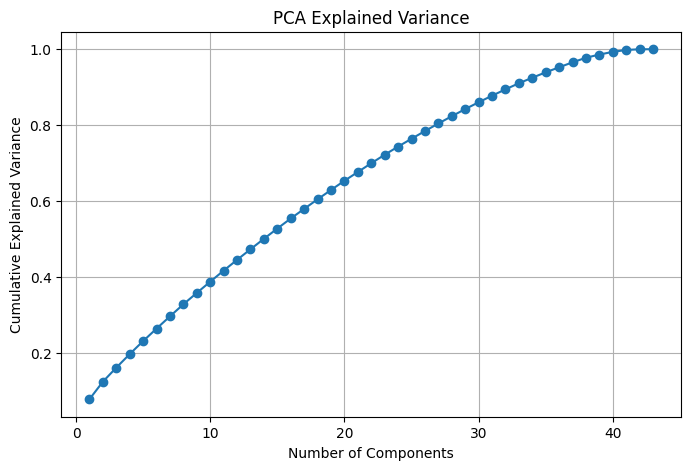

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)

plt.show()

PCA showed that approximately 37 principal components are required to preserve 95% of the variance in the dataset. This indicates that the Pokemon features contain information spread across many dimensions, and dimensionality reduction provides only limited compression.

## Conclusion

In this project, Pokemon battle data and Pokemon statistics were cleaned, merged, and analyzed to identify factors associated with battle success.

The missing Pokemon name (#62) was corrected, missing Type 2 values were replaced with "None", and win percentages were calculated using historical battle outcomes. After merging battle statistics with Pokemon attributes, exploratory data analysis was performed.

The correlation analysis revealed that Speed is the strongest predictor of battle performance, showing a very strong positive correlation with Win Percentage. Attack and Special Attack also demonstrated moderate positive relationships with battle success, while Generation had almost no impact.

Analysis of the top-performing Pokemon showed that many of them possess exceptionally high Speed and strong offensive stats, supporting the findings from the correlation matrix.

Three regression models were trained to predict Pokemon Win Percentage:

| Model | MAE |
|--------|--------|
| Linear Regression | 0.057 |
| Decision Tree Regressor | 0.053 |
| Random Forest Regressor | 0.042 |

Random Forest achieved the best performance with the lowest Mean Absolute Error, indicating that ensemble methods can capture complex relationships between Pokemon attributes and battle outcomes more effectively than simpler models.

Finally, PCA analysis showed that approximately 37 principal components are required to retain 95% of the dataset variance. This suggests that information is distributed across many features and that dimensionality reduction provides only limited compression for this dataset.

Overall, the project demonstrated how data cleaning, exploratory analysis, feature engineering, and machine learning can be combined to predict Pokemon battle performance and identify the attributes that contribute most to winning battles.